In [3]:
# !pip install pandas matplotlib seaborn scikit-learn

In [33]:
# !pip install koreanize-matplotlib

In [3]:
# !pip install notebook==6

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data= pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/iris3.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
data['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


<Axes: >

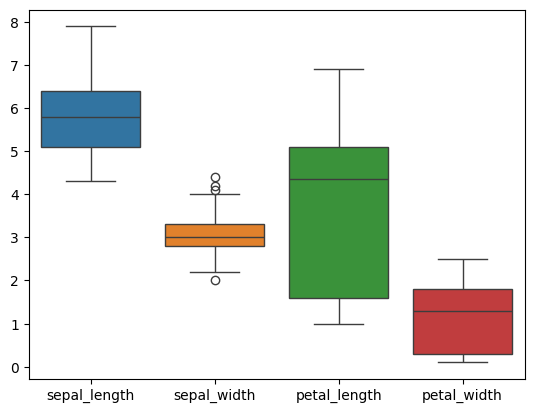

In [8]:
sns.boxplot(data)

In [9]:
data['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [10]:
X = data.drop("species", axis=1)
y = data["species"]

In [11]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)

In [12]:
y = pd.get_dummies(y)
y

,Iris-setosa,Iris-versicolor,Iris-virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
145,False,False,True
146,False,False,True
147,False,False,True
148,False,False,True


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [16]:
y_train

,Iris-setosa,Iris-versicolor,Iris-virginica
22,True,False,False
15,True,False,False
65,False,True,False
11,True,False,False
42,True,False,False
...,...,...,...
71,False,True,False
106,False,False,True
14,True,False,False
92,False,True,False


In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
mms = MinMaxScaler()
train_temp = mms.fit_transform(X_train)
test_temp = mms.transform(X_test)
mms_X_train = pd.DataFrame(train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index=X_test.index)

In [19]:
mms_X_train

,sepal_length,sepal_width,petal_length,petal_width
22,0.088235,0.666667,0.000000,0.041667
15,0.411765,1.000000,0.087719,0.125000
65,0.705882,0.458333,0.596491,0.541667
11,0.147059,0.583333,0.105263,0.041667
42,0.029412,0.500000,0.052632,0.041667
...,...,...,...,...
71,0.529412,0.333333,0.526316,0.500000
106,0.176471,0.208333,0.614035,0.666667
14,0.441176,0.833333,0.035088,0.041667
92,0.441176,0.250000,0.526316,0.458333


In [20]:
mms_X_test

,sepal_length,sepal_width,petal_length,petal_width
73,0.529412,0.333333,0.649123,0.458333
18,0.411765,0.750000,0.122807,0.083333
118,1.000000,0.250000,1.035088,0.916667
78,0.500000,0.375000,0.614035,0.583333
76,0.735294,0.333333,0.666667,0.541667
31,0.323529,0.583333,0.087719,0.125000
64,0.382353,0.375000,0.456140,0.500000
141,0.764706,0.458333,0.719298,0.916667
68,0.558824,0.083333,0.614035,0.583333
82,0.441176,0.291667,0.508772,0.458333


In [21]:
y_test  # 다중분류

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


# 텐서플로로 다중분류 분석하기

Sequential API

In [22]:
from keras.models import Sequential
from keras.layers import Dense, Input

2025-05-16 06:19:41.965258: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-16 06:19:42.290657: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-16 06:19:42.424622: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-16 06:19:42.458422: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-16 06:19:42.675377: I tensorflow/core/platform/cpu_feature_guar

In [23]:
model = Sequential()
model.add(Input(shape=(mms_X_train.shape[1], )))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation="softmax"))
model.summary()

I0000 00:00:1747376387.470718      26 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747376387.562130      26 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747376387.562180      26 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747376387.565083      26 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747376387.565169      26 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

* 다중분류의 경우 사용하는 loss
    * categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 one-hot encoding된 경우
    * sparse_categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 label encoding된 경우

Epoch 1/100


I0000 00:00:1747376389.583343     141 service.cc:146] XLA service 0x7f1904017b70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747376389.583402     141 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-16 06:19:49.649878: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-16 06:19:49.893840: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906


1/8 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.3125 - loss: 1.1162

I0000 00:00:1747376392.863964     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 274ms/step - accuracy: 0.3370 - loss: 1.1047 - val_accuracy: 0.3000 - val_loss: 1.1068
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3360 - loss: 1.0958 - val_accuracy: 0.3000 - val_loss: 1.1018
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3150 - loss: 1.0957 - val_accuracy: 0.3000 - val_loss: 1.0988
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3404 - loss: 1.0920 - val_accuracy: 0.3000 - val_loss: 1.0970
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4363 - loss: 1.0872 - val_accuracy: 0.4333 - val_loss: 1.0961
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3643 - loss: 1.0853 - val_accuracy: 0.3000 - val_loss: 1.0943
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4077 - loss: 1.0725 - val_accuracy: 0.5000 - val_loss: 1.0922
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5849 - loss: 1.0785 - val_accuracy: 0.5333 - val_loss: 1.0900
Epoch 9/10

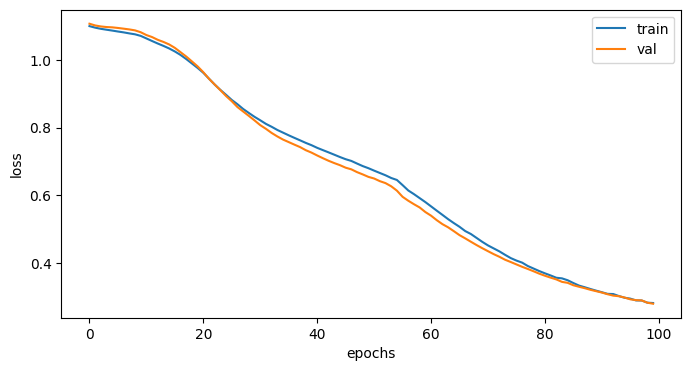

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,1.601211e-03,0.953290,0.045108
18,True,False,False,6.003488e-01,0.210202,0.189449
118,False,False,True,4.240434e-08,0.000955,0.999045
78,False,True,False,1.636975e-03,0.836225,0.162138
76,False,True,False,6.213463e-04,0.836131,0.163248
31,True,False,False,5.959913e-01,0.215705,0.188303
64,False,True,False,6.887268e-03,0.935023,0.058090
141,False,False,True,8.716840e-06,0.020081,0.979910
68,False,True,False,3.804255e-04,0.278641,0.720978
82,False,True,False,4.216598e-03,0.941897,0.053887


In [24]:
model.compile(loss="categorical_crossentropy",
             optimizer='adam',
             metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                   validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result

In [25]:
y_test

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


In [26]:
pd.DataFrame(pred)

,0,1,2
73,1.601211e-03,0.953290,0.045108
18,6.003488e-01,0.210202,0.189449
118,4.240434e-08,0.000955,0.999045
78,1.636975e-03,0.836225,0.162138
76,6.213463e-04,0.836131,0.163248
31,5.959913e-01,0.215705,0.188303
64,6.887268e-03,0.935023,0.058090
141,8.716840e-06,0.020081,0.979910
68,3.804255e-04,0.278641,0.720978
82,4.216598e-03,0.941897,0.053887


Funtional API

In [27]:
from keras.models import Model

In [28]:
inputs = Input(shape=(mms_X_train.shape[1],))
x = Dense(16, activation='relu')(inputs)
x = Dense(8, activation='relu')(x)
x = Dense(4, activation='relu')(x)
outputs = Dense(3, activation='softmax')(x)
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 356ms/step - accuracy: 0.3739 - loss: 1.2500 - val_accuracy: 0.3333 - val_loss: 1.2774
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3318 - loss: 1.2293 - val_accuracy: 0.3333 - val_loss: 1.2104
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3660 - loss: 1.1724 - val_accuracy: 0.4000 - val_loss: 1.1627
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4348 - loss: 1.1147 - val_accuracy: 0.5333 - val_loss: 1.1207
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5670 - loss: 1.0932 - val_accuracy: 0.5667 - val_loss: 1.0833
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6414 - loss: 1.0564 - val_accuracy: 0.5667 - val_loss: 1.0491
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5697 - loss: 1.0403 - val_accuracy: 0.5667 - val_loss: 1.0169
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6374 - loss: 0.9953 - val_accuracy: 0.6333 - val_loss

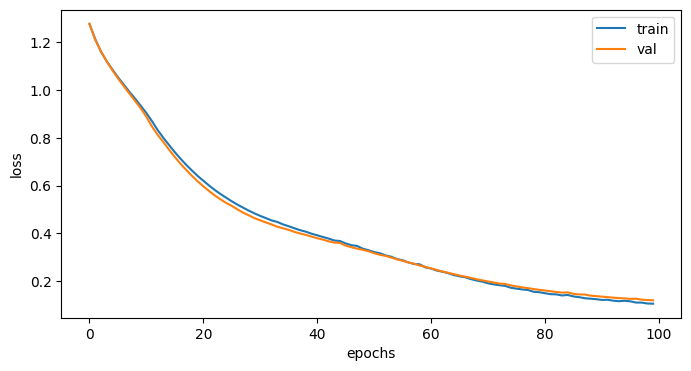

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,1.270354e-03,0.913556,8.517405e-02
18,True,False,False,9.935442e-01,0.006456,6.777682e-09
118,False,False,True,6.156545e-10,0.007623,9.923776e-01
78,False,True,False,5.013147e-04,0.834374,1.651243e-01
76,False,True,False,1.721929e-04,0.774700,2.251275e-01
31,True,False,False,9.895012e-01,0.010499,3.327253e-08
64,False,True,False,1.700658e-02,0.971947,1.104637e-02
141,False,False,True,9.977456e-08,0.054478,9.455223e-01
68,False,True,False,1.930892e-05,0.266585,7.333954e-01
82,False,True,False,7.400090e-03,0.966927,2.567307e-02


In [29]:
model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result

Subclass API

In [30]:
class Iris(Model):
    def __init__(self):
        super(Iris, self).__init__()
        self.dense1 = Dense(16, activation='relu')
        self.dense2 = Dense(8, activation='relu')        
        self.dense3 = Dense(4, activation='relu')
        self.classifier = Dense(3, activation='softmax')
        
    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)        
        return self.classifier(x)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 265ms/step - accuracy: 0.3175 - loss: 1.0830 - val_accuracy: 0.3667 - val_loss: 1.0499
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2743 - loss: 1.0810 - val_accuracy: 0.3667 - val_loss: 1.0375
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3761 - loss: 1.0463 - val_accuracy: 0.3667 - val_loss: 1.0264
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3450 - loss: 1.0472 - val_accuracy: 0.3667 - val_loss: 1.0160
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3652 - loss: 1.0391 - val_accuracy: 0.4000 - val_loss: 1.0048
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3686 - loss: 1.0406 - val_accuracy: 0.5333 - val_loss: 0.9932
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4788 - loss: 1.0096 - val_accuracy: 0.5333 - val_loss: 0.9798
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5124 - loss: 0.9907 - val_accuracy: 0.5667 - val_loss

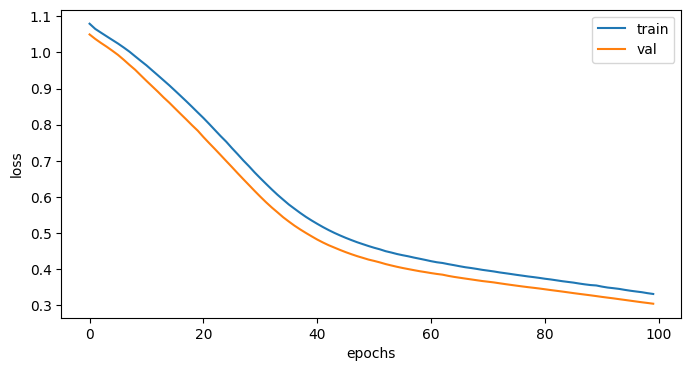

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,0.051616,0.524560,0.423824
18,True,False,False,0.996162,0.001569,0.002269
118,False,False,True,0.000025,0.076486,0.923489
78,False,True,False,0.028246,0.478851,0.492902
76,False,True,False,0.016757,0.435155,0.548088
31,True,False,False,0.991288,0.003974,0.004738
64,False,True,False,0.117148,0.563389,0.319464
141,False,False,True,0.000681,0.200762,0.798557
68,False,True,False,0.005360,0.340290,0.654351
82,False,True,False,0.094593,0.557421,0.347985


In [31]:
model2 = Iris()
model2.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
history = model2.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(mms_X_test, y_test))
pred = model2.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result